# Catan chip swap score tester

This notebook compares the saved reference edge images in `chips_temps` with the live/current edge images in `chips_current`.

Goal:
- See why swapped chips still score around `0.7`
- Build a full temp-vs-current score matrix
- Test one temp tile against all current tiles
- Try alternative comparison scores side by side

In [70]:
from pathlib import Path
import re
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Change this only if your folder is somewhere else
BASE_DIR = Path("../data/output/board_state_live")
TEMPS_DIR = BASE_DIR / "chips_temps"
CURRENT_DIR = BASE_DIR / "chips_current"

EDGE_SIZE = 112

print("temps dir:", TEMPS_DIR.resolve())
print("current dir:", CURRENT_DIR.resolve())
print("temps exists:", TEMPS_DIR.exists())
print("current exists:", CURRENT_DIR.exists())

temps dir: /home/younism/Desktop/FHGR/BildverarbeitungProject/catan-vision/data/output/board_state_live/chips_temps
current dir: /home/younism/Desktop/FHGR/BildverarbeitungProject/catan-vision/data/output/board_state_live/chips_current
temps exists: True
current exists: True


## Helper functions

These functions load `tile_X_edges.png`, calculate scores, and display results.

In [71]:
def tile_id_from_name(path: Path):
    m = re.search(r"tile_(\d+)_edges\.png$", path.name)
    return int(m.group(1)) if m else None


def inner_chip_mask(shape, radius_scale=0.68):
    h, w = shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)
    cx = w // 2
    cy = h // 2
    r = int(round(min(h, w) * 0.5 * radius_scale))
    cv2.circle(mask, (cx, cy), r, 255, -1)
    return mask


def remove_outer_circle(img, radius_scale=0.68):
    mask = inner_chip_mask(img.shape, radius_scale=radius_scale)
    return cv2.bitwise_and(img, img, mask=mask)


def load_edge_images(folder: Path, remove_ring=True):
    images = {}
    for path in sorted(folder.glob("tile_*_edges.png"), key=lambda p: tile_id_from_name(p) or -1):
        tile_id = tile_id_from_name(path)
        if tile_id is None:
            continue

        img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            print("Could not read:", path)
            continue

        if remove_ring:
            img = remove_outer_circle(img, radius_scale=0.68)

        images[tile_id] = img
    return images


def blank_edges(size=EDGE_SIZE):
    return np.zeros((size, size), dtype=np.uint8)


def ensure_binary(img):
    return ((img > 0).astype(np.uint8) * 255)


def show_edges(img, title=""):
    plt.figure(figsize=(3, 3))
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

## Load temp and current edge images

In [72]:
temps = load_edge_images(TEMPS_DIR)
currents = load_edge_images(CURRENT_DIR)

all_tile_ids = sorted(set(temps) | set(currents))

print("temp tiles:   ", sorted(temps.keys()))
print("current tiles:", sorted(currents.keys()))
print("number of temp images:", len(temps))
print("number of current images:", len(currents))

temp tiles:    [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
current tiles: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
number of temp images: 19
number of current images: 19


## Original score from `number_detection.py`

This is copied from your current algorithm so we can reproduce the exact same score.

In [73]:
def original_edge_similarity(edges_a, edges_b):
    # Your current structure-based score. Higher is better.
    if edges_a is None or edges_b is None:
        return -1.0
    if edges_a.shape != edges_b.shape:
        return -1.0

    a = ensure_binary(edges_a)
    b = ensure_binary(edges_b)

    kernel = np.ones((3, 3), np.uint8)
    a = cv2.dilate(a, kernel, iterations=1)
    b = cv2.dilate(b, kernel, iterations=1)

    def features(img):
        white = int(np.count_nonzero(img))
        num_labels, _, stats, _ = cv2.connectedComponentsWithStats(img, connectivity=8)

        comp_areas = []
        xs, ys, xe, ye = [], [], [], []
        for i in range(1, num_labels):
            area = int(stats[i, cv2.CC_STAT_AREA])
            if area < 8:
                continue
            comp_areas.append(area)
            x = int(stats[i, cv2.CC_STAT_LEFT])
            y = int(stats[i, cv2.CC_STAT_TOP])
            w = int(stats[i, cv2.CC_STAT_WIDTH])
            h = int(stats[i, cv2.CC_STAT_HEIGHT])
            xs.append(x)
            ys.append(y)
            xe.append(x + w)
            ye.append(y + h)

        comp_count = len(comp_areas)
        if comp_count == 0:
            bbox_w = 0
            bbox_h = 0
        else:
            bbox_w = max(xe) - min(xs)
            bbox_h = max(ye) - min(ys)

        return {
            "white": white,
            "comp_count": comp_count,
            "bbox_w": bbox_w,
            "bbox_h": bbox_h,
        }

    fa = features(a)
    fb = features(b)

    white_sim = 1.0 - abs(fa["white"] - fb["white"]) / max(1, max(fa["white"], fb["white"]))
    comp_sim = 1.0 if fa["comp_count"] == fb["comp_count"] else max(
        0.0, 1.0 - abs(fa["comp_count"] - fb["comp_count"]) / 3.0
    )
    bw_sim = 1.0 - abs(fa["bbox_w"] - fb["bbox_w"]) / max(1, max(fa["bbox_w"], fb["bbox_w"], 1))
    bh_sim = 1.0 - abs(fa["bbox_h"] - fb["bbox_h"]) / max(1, max(fa["bbox_h"], fb["bbox_h"], 1))

    score = 0.40 * white_sim + 0.30 * comp_sim + 0.15 * bw_sim + 0.15 * bh_sim
    return float(score)

## Alternative scoring functions

Your current score can stay high after a swap because it compares broad shape statistics, not exact edge position. These alternatives test stricter matching.

In [74]:
def iou_score(edges_a, edges_b, dilation=1):
    # Pixel overlap score. More strict than the original feature score.
    if edges_a is None or edges_b is None or edges_a.shape != edges_b.shape:
        return -1.0
    a = ensure_binary(edges_a)
    b = ensure_binary(edges_b)
    if dilation > 0:
        kernel = np.ones((3, 3), np.uint8)
        a = cv2.dilate(a, kernel, iterations=dilation)
        b = cv2.dilate(b, kernel, iterations=dilation)
    aa = a > 0
    bb = b > 0
    inter = np.count_nonzero(aa & bb)
    union = np.count_nonzero(aa | bb)
    return float(inter / union) if union > 0 else 1.0


def dice_score(edges_a, edges_b, dilation=1):
    # Pixel overlap score, less harsh than IoU.
    if edges_a is None or edges_b is None or edges_a.shape != edges_b.shape:
        return -1.0
    a = ensure_binary(edges_a)
    b = ensure_binary(edges_b)
    if dilation > 0:
        kernel = np.ones((3, 3), np.uint8)
        a = cv2.dilate(a, kernel, iterations=dilation)
        b = cv2.dilate(b, kernel, iterations=dilation)
    aa = a > 0
    bb = b > 0
    inter = np.count_nonzero(aa & bb)
    total = np.count_nonzero(aa) + np.count_nonzero(bb)
    return float((2 * inter) / total) if total > 0 else 1.0


def template_corr_score(edges_a, edges_b):
    # Normalized correlation. Sensitive to exact structure but affected by small shifts.
    if edges_a is None or edges_b is None or edges_a.shape != edges_b.shape:
        return -1.0
    a = edges_a.astype(np.float32) / 255.0
    b = edges_b.astype(np.float32) / 255.0
    a = a - a.mean()
    b = b - b.mean()
    denom = np.sqrt(np.sum(a * a) * np.sum(b * b))
    if denom < 1e-8:
        return 1.0 if np.sum(edges_a) == np.sum(edges_b) else 0.0
    return float((np.sum(a * b) / denom + 1.0) / 2.0)


def chamfer_score(edges_a, edges_b, max_dist=12):
    # Distance-transform score. Good when the same chip moved a few pixels.
    if edges_a is None or edges_b is None or edges_a.shape != edges_b.shape:
        return -1.0
    a = ensure_binary(edges_a)
    b = ensure_binary(edges_b)
    a_pts = a > 0
    b_pts = b > 0
    if np.count_nonzero(a_pts) == 0 and np.count_nonzero(b_pts) == 0:
        return 1.0
    if np.count_nonzero(a_pts) == 0 or np.count_nonzero(b_pts) == 0:
        return 0.0

    dist_to_b = cv2.distanceTransform(255 - b, cv2.DIST_L2, 3)
    dist_to_a = cv2.distanceTransform(255 - a, cv2.DIST_L2, 3)

    d1 = float(np.mean(np.clip(dist_to_b[a_pts], 0, max_dist)))
    d2 = float(np.mean(np.clip(dist_to_a[b_pts], 0, max_dist)))
    d = 0.5 * (d1 + d2)
    return float(max(0.0, 1.0 - d / max_dist))


SCORERS = {
    "original": original_edge_similarity,
    "iou": iou_score,
    "dice": dice_score,
    "corr": template_corr_score,
    "chamfer": chamfer_score,
}

## Compare same tile IDs: `temps/tile_X` vs `current/tile_X`

This shows the score your live debug report prints, plus alternative scores.

In [75]:
rows = []
for tile_id in all_tile_ids:
    temp_img = temps.get(tile_id, blank_edges())
    curr_img = currents.get(tile_id, blank_edges())
    row = {"tile_id": tile_id}
    for name, scorer in SCORERS.items():
        row[name] = scorer(curr_img, temp_img)
    rows.append(row)

same_tile_df = pd.DataFrame(rows).sort_values("tile_id")
same_tile_df

,tile_id,original,iou,dice,corr,chamfer
0,0,0.681101,0.363065,0.532719,0.555765,0.866886
1,1,0.985530,0.494812,0.662039,0.631791,0.909189
2,2,0.982272,0.677632,0.807843,0.698674,0.940916
3,3,0.888032,0.384221,0.555144,0.591239,0.823190
4,4,0.867883,0.316779,0.481142,0.568216,0.841155
5,5,0.601262,0.163373,0.280861,0.525832,0.734634
6,6,0.981265,0.409283,0.580838,0.585602,0.884659
7,7,0.785430,0.734428,0.846882,0.793263,0.957035
8,8,1.000000,1.000000,1.000000,1.000000,1.000000
9,9,0.916187,0.269705,0.424831,0.571428,0.805236


In [76]:
# Sort by the original score, lowest first
same_tile_df .sort_values("dice")

,tile_id,original,iou,dice,corr,chamfer
14,14,0.720273,0.160129,0.276054,0.530441,0.692402
5,5,0.601262,0.163373,0.280861,0.525832,0.734634
18,18,0.759481,0.207557,0.343764,0.529361,0.776910
12,12,0.867896,0.237324,0.383608,0.555764,0.799488
9,9,0.916187,0.269705,0.424831,0.571428,0.805236
11,11,0.884224,0.293714,0.454063,0.583462,0.778796
13,13,0.998510,0.293905,0.454291,0.540232,0.836459
4,4,0.867883,0.316779,0.481142,0.568216,0.841155
10,10,0.869220,0.355632,0.524673,0.589973,0.870392
17,17,0.847550,0.358621,0.527919,0.589937,0.837751


## Full score matrix

Rows are `current/tile_X_edges.png`.
Columns are `temps/tile_Y_edges.png`.

If a chip moved from temp tile 12 to current tile 8, then row `current_8` should have its highest score under column `temp_12`.

In [77]:
def build_score_matrix(scorer_name="original"):
    scorer = SCORERS[scorer_name]
    current_ids = sorted(currents.keys())
    temp_ids = sorted(temps.keys())
    data = []
    for current_id in current_ids:
        row = []
        for temp_id in temp_ids:
            row.append(scorer(currents[current_id], temps[temp_id]))
        data.append(row)
    return pd.DataFrame(
        data,
        index=[f"current_{i}" for i in current_ids],
        columns=[f"temp_{i}" for i in temp_ids],
    )

matrix_original = build_score_matrix("original")
matrix_original

,temp_0,temp_1,temp_2,temp_3,temp_4,temp_5,temp_6,temp_7,temp_8,temp_9,temp_10,temp_11,temp_12,temp_13,temp_14,temp_15,temp_16,temp_17,temp_18
current_0,0.681101,0.627318,0.427778,0.576478,0.586728,0.559398,0.527774,0.554829,0.0,0.623874,0.606639,0.594660,0.561889,0.627468,0.604261,0.670833,0.613721,0.633079,0.619816
current_1,0.936972,0.985530,0.610021,0.834792,0.790433,0.806207,0.707922,0.661064,0.0,0.925571,0.862581,0.961835,0.840281,0.937141,0.861447,0.824754,0.860082,0.713091,0.860196
current_2,0.638922,0.624803,0.982272,0.480136,0.463771,0.680853,0.869210,0.344862,0.1,0.591322,0.539745,0.615267,0.736113,0.654354,0.536666,0.553269,0.740737,0.675567,0.741155
current_3,0.686282,0.732529,0.381694,0.888032,0.844958,0.659461,0.470156,0.911084,0.0,0.750242,0.809123,0.737582,0.598391,0.683888,0.804576,0.775739,0.607344,0.564511,0.610262
current_4,0.653199,0.656839,0.345068,0.818406,0.867883,0.638129,0.421618,0.987002,0.0,0.718535,0.742937,0.662293,0.546262,0.616687,0.734801,0.735678,0.541019,0.501087,0.541648
current_5,0.709170,0.769769,0.416946,0.822504,0.785300,0.601262,0.516507,0.855571,0.0,0.720375,0.872461,0.787152,0.648443,0.744011,0.867573,0.796679,0.670561,0.624286,0.675318
current_6,0.740478,0.731385,0.845018,0.573430,0.550031,0.772426,0.981265,0.425664,0.1,0.684997,0.651714,0.720181,0.867701,0.771456,0.648784,0.649248,0.852842,0.790387,0.851080
current_7,0.857674,0.861111,0.547317,0.823329,0.873329,0.843211,0.624576,0.785430,0.0,0.923543,0.746980,0.866614,0.749457,0.820523,0.738822,0.740009,0.745054,0.604900,0.745799
current_8,0.000000,0.000000,0.100000,0.000000,0.000000,0.100000,0.100000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.100000,0.200000,0.100000
current_9,0.990696,0.931445,0.637874,0.781445,0.771009,0.763313,0.730461,0.639405,0.0,0.916187,0.809151,0.898202,0.864657,0.927993,0.807011,0.886865,0.816416,0.741748,0.822400


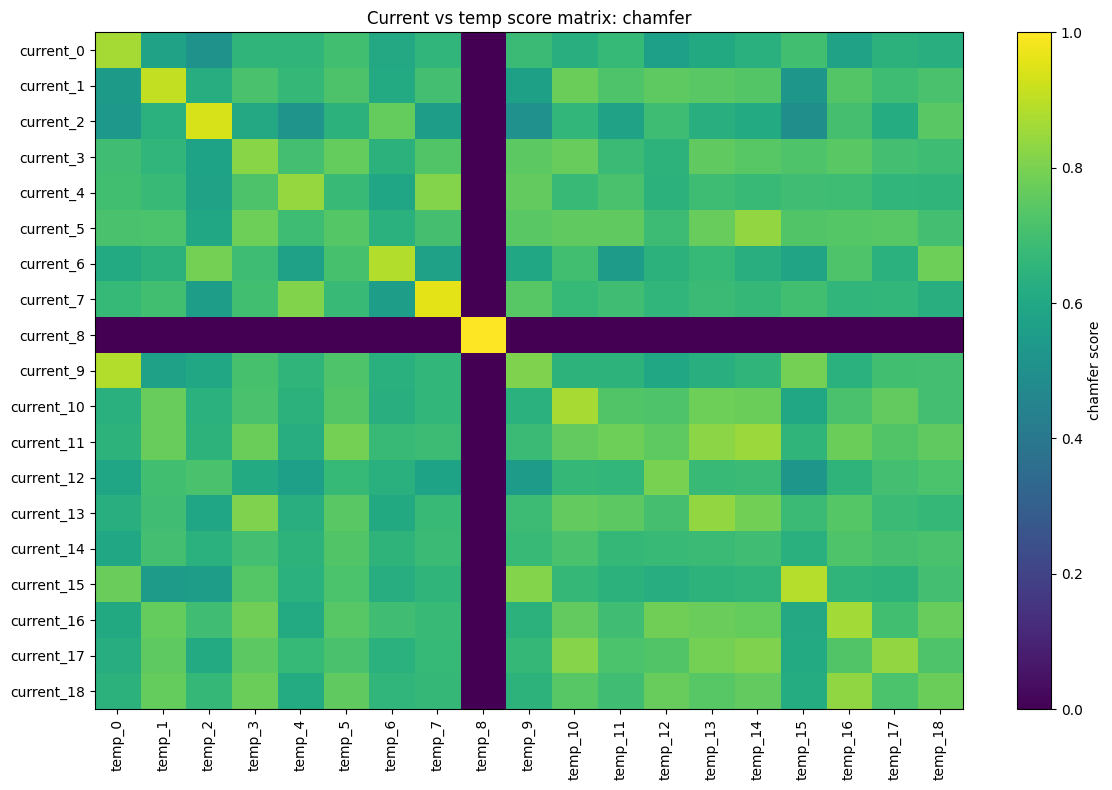

,temp_0,temp_1,temp_2,temp_3,temp_4,temp_5,temp_6,temp_7,temp_8,temp_9,temp_10,temp_11,temp_12,temp_13,temp_14,temp_15,temp_16,temp_17,temp_18
current_0,0.866886,0.576665,0.514139,0.655481,0.656241,0.698481,0.605045,0.658672,0.0,0.681122,0.626875,0.671578,0.562838,0.608436,0.633662,0.696104,0.577759,0.644082,0.631962
current_1,0.545724,0.909189,0.623948,0.712682,0.664303,0.719796,0.611146,0.700393,0.0,0.569679,0.774967,0.723635,0.751872,0.746001,0.732448,0.529485,0.730588,0.688858,0.712793
current_2,0.532063,0.638644,0.940916,0.604279,0.519259,0.640743,0.764058,0.562400,0.0,0.507429,0.662761,0.577806,0.688019,0.629498,0.610941,0.498110,0.703268,0.619675,0.744943
current_3,0.693206,0.656459,0.579022,0.823190,0.699919,0.762191,0.643961,0.726834,0.0,0.748421,0.768154,0.683408,0.647029,0.754572,0.742125,0.725922,0.743522,0.703120,0.688058
current_4,0.697038,0.675584,0.574795,0.721023,0.841155,0.677683,0.589565,0.816059,0.0,0.760614,0.675708,0.713240,0.641447,0.689885,0.678559,0.692216,0.690069,0.656496,0.654479
current_5,0.713898,0.716881,0.596228,0.779544,0.688185,0.734634,0.638204,0.706667,0.0,0.745729,0.754120,0.756232,0.686249,0.767161,0.837145,0.727066,0.734794,0.739141,0.701208
current_6,0.611799,0.643248,0.791647,0.688385,0.571788,0.708400,0.884659,0.571637,0.0,0.599030,0.698015,0.549975,0.641585,0.670554,0.631206,0.584266,0.725047,0.640153,0.778859
current_7,0.670592,0.695591,0.561457,0.697668,0.812020,0.678947,0.555352,0.957035,0.0,0.738315,0.668048,0.692321,0.657281,0.680936,0.666467,0.695924,0.657703,0.662087,0.630168
current_8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
current_9,0.886280,0.571184,0.597943,0.707415,0.653267,0.726298,0.634168,0.663249,0.0,0.805236,0.647100,0.645088,0.599860,0.631092,0.654523,0.791357,0.638929,0.695962,0.702882


In [78]:
# Try changing this to: "original", "iou", "dice", "corr", or "chamfer"
SCORER_TO_VIEW = "chamfer"

matrix = build_score_matrix(SCORER_TO_VIEW)
plt.figure(figsize=(12, 8))
plt.imshow(matrix.values, aspect="auto")
plt.colorbar(label=f"{SCORER_TO_VIEW} score")
plt.xticks(range(len(matrix.columns)), matrix.columns, rotation=90)
plt.yticks(range(len(matrix.index)), matrix.index)
plt.title(f"Current vs temp score matrix: {SCORER_TO_VIEW}")
plt.tight_layout()
plt.show()

matrix

## Best matching temp tile for each current tile

This is the most important table for swap detection.

In [79]:
def best_matches(scorer_name="original"):
    matrix = build_score_matrix(scorer_name)
    rows = []
    for current_label, row in matrix.iterrows():
        best_temp_label = row.idxmax()
        best_score = float(row.max())
        current_id = int(current_label.split("_")[1])
        best_temp_id = int(best_temp_label.split("_")[1])
        self_col = f"temp_{current_id}"
        self_score = float(row[self_col]) if self_col in row.index else np.nan
        rows.append({
            "current_tile": current_id,
            "best_temp_tile": best_temp_id,
            "best_score": best_score,
            "self_score": self_score,
            "improvement": best_score - self_score,
            "possible_changed": best_temp_id != current_id,
        })
    return pd.DataFrame(rows).sort_values("current_tile")

# Try: "original", "iou", "dice", "corr", "chamfer"
MATCH_SCORER = "chamfer"
best_df = best_matches(MATCH_SCORER)
best_df

,current_tile,best_temp_tile,best_score,self_score,improvement,possible_changed
0,0,0,0.866886,0.866886,0.000000,False
1,1,1,0.909189,0.909189,0.000000,False
2,2,2,0.940916,0.940916,0.000000,False
3,3,3,0.823190,0.823190,0.000000,False
4,4,4,0.841155,0.841155,0.000000,False
5,5,14,0.837145,0.734634,0.102511,True
6,6,6,0.884659,0.884659,0.000000,False
7,7,7,0.957035,0.957035,0.000000,False
8,8,8,1.000000,1.000000,0.000000,False
9,9,0,0.886280,0.805236,0.081043,True


In [80]:
# Show only possible changed tiles
best_df[best_df["possible_changed"]].sort_values("improvement", ascending=False)

,current_tile,best_temp_tile,best_score,self_score,improvement,possible_changed
5,5,14,0.837145,0.734634,0.102511,True
9,9,0,0.886280,0.805236,0.081043,True
11,11,14,0.851524,0.778796,0.072728,True
18,18,16,0.832199,0.776910,0.055289,True
14,14,5,0.726942,0.692402,0.034540,True


## Test one temp image against all current images

Set `TEMP_TILE_TO_TEST` to the tile you want. This answers your exact question: run one temp image with all images in current and see what scores we get.

In [99]:
TEMP_TILE_TO_TEST = 0
# Change this tile number
TEST_SCORER = "dice"   # Try: original, iou, dice, corr, chamfer

scorer = SCORERS[TEST_SCORER]
temp_img = temps[TEMP_TILE_TO_TEST]

rows = []
for current_id, current_img in sorted(currents.items()):
    rows.append({
        "temp_tile": TEMP_TILE_TO_TEST,
        "current_tile": current_id,
        "score": scorer(current_img, temp_img),
        "same_tile": current_id == TEMP_TILE_TO_TEST,
    })

test_df = pd.DataFrame(rows).sort_values("score", ascending=False)
test_df

,temp_tile,current_tile,score,same_tile
9,0,9,0.582605,False
0,0,0,0.532719,True
15,0,15,0.332714,False
5,0,5,0.322693,False
3,0,3,0.301763,False
18,0,18,0.277651,False
10,0,10,0.275444,False
4,0,4,0.261668,False
12,0,12,0.251546,False
11,0,11,0.248927,False


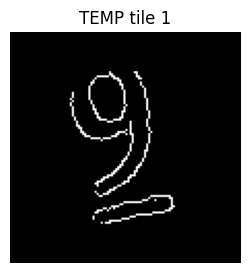

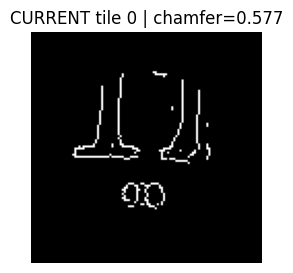

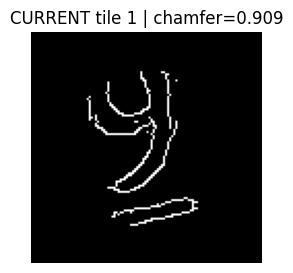

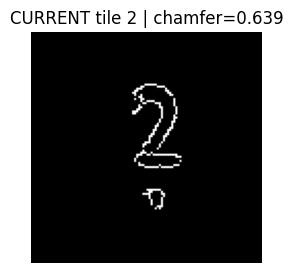

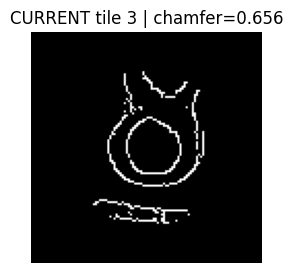

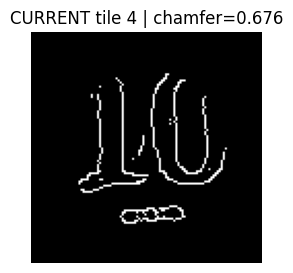

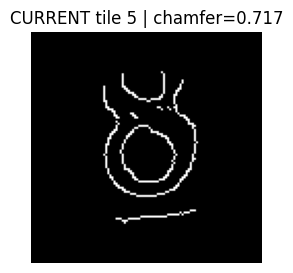

In [82]:
# Visualize the tested temp tile and the best current matches
TOP_N = 6
best_rows = test_df.head(TOP_N)

show_edges(temps[TEMP_TILE_TO_TEST], title=f"TEMP tile {TEMP_TILE_TO_TEST}")

for _, row in best_rows.iterrows():
    current_tile = int(row["current_tile"])
    score = float(row["score"])
    show_edges(currents[current_tile], title=f"CURRENT tile {current_tile} | {TEST_SCORER}={score:.3f}")

## Compare two selected tiles visually

Use this if you suspect a specific swap, for example tile 8 and tile 12.

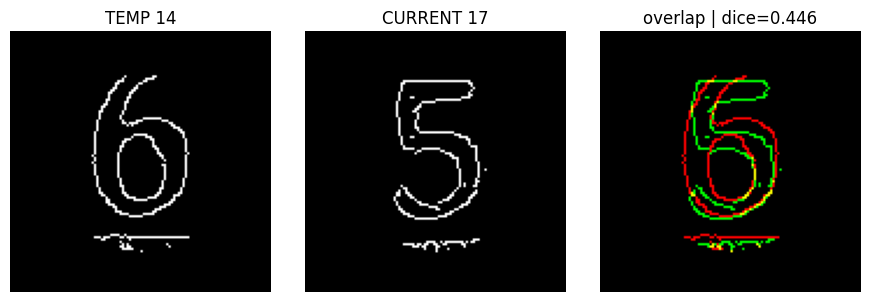

In [105]:
CURRENT_TILE = 17
TEMP_TILE = 14
VIS_SCORER = "dice"

curr_img = currents[CURRENT_TILE]
temp_img = temps[TEMP_TILE]
score = SCORERS[VIS_SCORER](curr_img, temp_img)

plt.figure(figsize=(9, 3))
plt.subplot(1, 3, 1)
plt.imshow(temp_img, cmap="gray")
plt.title(f"TEMP {TEMP_TILE}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(curr_img, cmap="gray")
plt.title(f"CURRENT {CURRENT_TILE}")
plt.axis("off")

# overlap image: temp in red channel, current in green channel
h, w = temp_img.shape
rgb = np.zeros((h, w, 3), dtype=np.uint8)
rgb[:, :, 0] = ensure_binary(temp_img)
rgb[:, :, 1] = ensure_binary(curr_img)
plt.subplot(1, 3, 3)
plt.imshow(rgb)
plt.title(f"overlap | {VIS_SCORER}={score:.3f}")
plt.axis("off")

plt.tight_layout()
plt.show()

In [84]:
same_tile_df

,tile_id,original,iou,dice,corr,chamfer
0,0,0.681101,0.363065,0.532719,0.555765,0.866886
1,1,0.985530,0.494812,0.662039,0.631791,0.909189
2,2,0.982272,0.677632,0.807843,0.698674,0.940916
3,3,0.888032,0.384221,0.555144,0.591239,0.823190
4,4,0.867883,0.316779,0.481142,0.568216,0.841155
5,5,0.601262,0.163373,0.280861,0.525832,0.734634
6,6,0.981265,0.409283,0.580838,0.585602,0.884659
7,7,0.785430,0.734428,0.846882,0.793263,0.957035
8,8,1.000000,1.000000,1.000000,1.000000,1.000000
9,9,0.916187,0.269705,0.424831,0.571428,0.805236


## Recommended next step

Use the tables above to compare algorithms:

- If `original` gives many wrong high scores around `0.7`, it is too weak.
- If `chamfer` gives the correct moved chip as the best match, it is probably better for your swap detection.
- If `iou` or `dice` are too low even for the same chip, your crop is moving too much between frames.

In [100]:
# Test every TEMP tile against all CURRENT tiles
# Print only top 2 matches for each tile

TEST_SCORER = "dice"   # original, iou, dice, corr, chamfer

scorer = SCORERS[TEST_SCORER]

all_rows = []

for temp_tile_id, temp_img in sorted(temps.items()):
    rows = []

    for current_id, current_img in sorted(currents.items()):
        score = scorer(current_img, temp_img)

        rows.append({
            "temp_tile": temp_tile_id,
            "current_tile": current_id,
            "score": score,
            "same_tile": current_id == temp_tile_id
        })

    df = pd.DataFrame(rows).sort_values("score", ascending=False).head(2)
    all_rows.append(df)

result_df = pd.concat(all_rows, ignore_index=True)

result_df

,temp_tile,current_tile,score,same_tile
0,0,9,0.582605,False
1,0,0,0.532719,True
2,1,1,0.662039,True
3,1,18,0.404444,False
4,2,2,0.807843,True
5,2,6,0.405167,False
6,3,3,0.555144,True
7,3,13,0.456790,False
8,4,4,0.481142,True
9,4,7,0.412427,False


In [101]:
# Show only rows where same_tile == True
# (best self-match rows from the previous result_df)

true_df = result_df[result_df["same_tile"] == True].copy()

true_df = true_df.sort_values("temp_tile").reset_index(drop=True)

true_df

,temp_tile,current_tile,score,same_tile
0,0,0,0.532719,True
1,1,1,0.662039,True
2,2,2,0.807843,True
3,3,3,0.555144,True
4,4,4,0.481142,True
5,6,6,0.580838,True
6,7,7,0.846882,True
7,8,8,1.000000,True
8,9,9,0.424831,True
9,10,10,0.524673,True


In [102]:
# For every TEMP tile, print only the 3rd best match score

TEST_SCORER = "dice"   # original, iou, dice, corr, chamfer

scorer = SCORERS[TEST_SCORER]

third_rows = []

for temp_tile_id, temp_img in sorted(temps.items()):
    rows = []

    for current_id, current_img in sorted(currents.items()):
        rows.append({
            "temp_tile": temp_tile_id,
            "current_tile": current_id,
            "score": scorer(current_img, temp_img),
            "same_tile": current_id == temp_tile_id
        })

    df = pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)

    if len(df) >= 3:
        third_rows.append(df.iloc[2])   # index 2 = 3rd best

third_best_df = pd.DataFrame(third_rows).reset_index(drop=True)

third_best_df

,temp_tile,current_tile,score,same_tile
0,0,15,0.332714,False
1,1,16,0.398959,False
2,2,12,0.357337,False
3,3,16,0.449921,False
4,4,17,0.306299,False
5,5,16,0.376291,False
6,6,18,0.297718,False
7,7,16,0.363034,False
8,8,0,0.000000,False
9,9,3,0.399393,False
